# D2C Customer Churn Intelligence & Retention API

## Part 2: RFM Segmentation & Retention Strategy

### Student Details

**Name:** Mayank Sharma

**Student_ID:** iitp_aiml_2506012

---

## Objective

The objective of this analysis is to identify customer segments that require retention attention before deploying a machine learning model.

This notebook uses customer purchase history to calculate Recency, Frequency, and Monetary (RFM) metrics. These metrics are combined with additional behavioural signals such as support complaints, return behaviour, campaign engagement, and loyalty membership information to create meaningful customer segments.

The analysis aims to:

- Build customer-level RFM features
- Identify high-value and high-risk customer groups
- Create actionable customer segments
- Recommend retention strategies for each segment
- Prioritize retention investments under limited budget conditions
- Support business decision-making using data-driven customer intelligence

---

## Expected Deliverables

1. Customer RFM Feature Table
2. Customer Segmentation Logic
3. Segment-Level Business Analysis
4. Retention Strategy Recommendations
5. Budget Prioritization Framework
6. Manual Review Cases for Ambiguous Customers

# Import Required Libraries

The following libraries are used throughout the analysis:

### Pandas
Used for data loading, cleaning, aggregation, and customer-level feature engineering.

### NumPy
Used for numerical calculations and conditional logic.

### Matplotlib
Used for creating business-oriented visualizations.

### Seaborn
Used for statistical charts and customer segment analysis.

### Pathlib
Used for platform-independent file handling.

### Warnings
Used to suppress unnecessary warning messages for cleaner notebook output.

In [1]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

# Visualization Settings

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Define Dataset and Output Paths

The project datasets are stored inside the central Dataset folder.

Output charts and generated files will be stored inside the outputs folder of Part 2.

This helps keep the repository organized and ensures all deliverables are generated automatically.

In [3]:
# ============================================================
# DEFINE PATHS
# ============================================================

DATA_PATH = Path("../Datasets")

OUTPUT_PATH = Path("Outputs")

OUTPUT_PATH.mkdir(exist_ok=True)

print("Dataset Path :", DATA_PATH)
print("Output Path  :", OUTPUT_PATH)

Dataset Path : ..\Datasets
Output Path  : Outputs


# Load Required Datasets

The segmentation exercise requires information from multiple datasets.

### customers.csv
Contains customer demographic and loyalty information.

### orders.csv
Contains purchase transactions and revenue information.

### support_tickets.csv
Contains customer complaint and service information.

### web_events_snapshot.csv
Contains recent customer activity signals.

### intervention_history.csv
Contains previous campaign interaction information.

### churn_labels.csv
Contains churn outcome labels for validation purposes.

### rfm_modeling_snapshot.csv
Contains engineered behavioural features that can enrich segmentation.

In [4]:
# ============================================================
# LOAD DATASETS
# ============================================================

customers = pd.read_csv(DATA_PATH / "customers.csv")

orders = pd.read_csv(DATA_PATH / "orders.csv")

support_tickets = pd.read_csv(
    DATA_PATH / "support_tickets.csv"
)

web_events = pd.read_csv(
    DATA_PATH / "web_events_snapshot.csv"
)

intervention_history = pd.read_csv(
    DATA_PATH / "intervention_history.csv"
)

churn_labels = pd.read_csv(
    DATA_PATH / "churn_labels.csv"
)

rfm_snapshot = pd.read_csv(
    DATA_PATH / "rfm_modeling_snapshot.csv"
)

print("All datasets loaded successfully")

All datasets loaded successfully


# Quick Dataset Validation

Before building customer segments, it is important to verify that all datasets have been loaded correctly.

The following validation checks have been performed:

- Number of rows
- Number of columns
- Customer coverage
- Basic structural verification

In [5]:
# ============================================================
# DATASET VALIDATION
# ============================================================

dataset_summary = pd.DataFrame({

    "Dataset": [
        "customers",
        "orders",
        "support_tickets",
        "web_events",
        "intervention_history",
        "churn_labels",
        "rfm_snapshot"
    ],

    "Rows": [
        customers.shape[0],
        orders.shape[0],
        support_tickets.shape[0],
        web_events.shape[0],
        intervention_history.shape[0],
        churn_labels.shape[0],
        rfm_snapshot.shape[0]
    ],

    "Columns": [
        customers.shape[1],
        orders.shape[1],
        support_tickets.shape[1],
        web_events.shape[1],
        intervention_history.shape[1],
        churn_labels.shape[1],
        rfm_snapshot.shape[1]
    ]
})

dataset_summary

,Dataset,Rows,Columns
0,customers,2400,9
1,orders,10009,10
2,support_tickets,1921,8
3,web_events,2400,10
4,intervention_history,2400,5
5,churn_labels,2400,4
6,rfm_snapshot,2400,29


# Converting Date Columns

RFM analysis requires accurate date calculations.

The date columns have been converted into datetime format so that recency and customer lifecycle metrics can be calculated correctly.

In [6]:
# ============================================================
# DATE CONVERSIONS
# ============================================================

customers["signup_date"] = pd.to_datetime(
    customers["signup_date"]
)

orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

support_tickets["ticket_date"] = pd.to_datetime(
    support_tickets["ticket_date"]
)

print("Date conversion completed")

Date conversion completed


# RFM Feature Engineering

RFM stands for:

### Recency
How recently a customer made a purchase.

### Frequency
How often a customer purchases.

### Monetary Value
How much revenue a customer generates.

These three metrics form the foundation of customer segmentation and retention analysis.

In [7]:
# ============================================================
# DEFINE REFERENCE DATE
# ============================================================

reference_date = orders["order_date"].max()

print("Reference Date Used For RFM Analysis")
print(reference_date)

Reference Date Used For RFM Analysis
2025-11-29 00:00:00


In [8]:
# ============================================================
# CALCULATE RECENCY
# ============================================================

customer_recency = (
    orders
    .groupby("customer_id")
    .agg(
        last_order_date=("order_date", "max")
    )
    .reset_index()
)

customer_recency["recency_days"] = (
    reference_date -
    customer_recency["last_order_date"]
).dt.days

customer_recency.head()

,customer_id,last_order_date,recency_days
0,CUST00001,2025-06-15,167
1,CUST00002,2025-10-26,34
2,CUST00003,2025-04-12,231
3,CUST00004,2025-05-22,191
4,CUST00005,2025-11-19,10


In [9]:
# ============================================================
# CALCULATE FREQUENCY
# ============================================================

customer_frequency = (
    orders
    .groupby("customer_id")
    .agg(
        frequency=("order_id", "count")
    )
    .reset_index()
)

customer_frequency.head()

,customer_id,frequency
0,CUST00001,6
1,CUST00002,3
2,CUST00003,1
3,CUST00004,1
4,CUST00005,6


In [10]:
# ============================================================
# CALCULATE MONETARY VALUE
# ============================================================

customer_monetary = (
    orders
    .groupby("customer_id")
    .agg(
        monetary_value=("gross_amount", "sum")
    )
    .reset_index()
)

customer_monetary.head()

,customer_id,monetary_value
0,CUST00001,2955.57
1,CUST00002,1713.10
2,CUST00003,649.98
3,CUST00004,1604.04
4,CUST00005,3910.43


# Building Customer RFM Table

The Recency, Frequency, and Monetary metrics calculated separately will now be combined into a single customer-level RFM table.

Each row in this table represents one customer and summarizes their purchasing behaviour.

This table will become the foundation for customer segmentation.

In [11]:
# ============================================================
# MERGE RFM FEATURES
# ============================================================

rfm = customer_recency.merge(
    customer_frequency,
    on="customer_id"
)

rfm = rfm.merge(
    customer_monetary,
    on="customer_id"
)

rfm.head()

,customer_id,last_order_date,recency_days,frequency,monetary_value
0,CUST00001,2025-06-15,167,6,2955.57
1,CUST00002,2025-10-26,34,3,1713.10
2,CUST00003,2025-04-12,231,1,649.98
3,CUST00004,2025-05-22,191,1,1604.04
4,CUST00005,2025-11-19,10,6,3910.43


# Validate RFM Table

Before assigning scores, we verify that:

- Every customer appears only once
- No RFM values are missing
- Customer coverage is complete

In [12]:
# ============================================================
# RFM VALIDATION
# ============================================================

print("Total Customers:", rfm.shape[0])

print("Unique Customers:",
      rfm["customer_id"].nunique())

print("\nMissing Values")

display(rfm.isnull().sum())

Total Customers: 2400
Unique Customers: 2400

Missing Values


customer_id        0
last_order_date    0
recency_days       0
frequency          0
monetary_value     0
dtype: int64

# Creating RFM Scores

Raw values are difficult to compare directly.

Therefore, customers will be converted into percentile-based scores.

### Recency Score

Lower recency is better.

Customers who purchased recently receive higher scores.

### Frequency Score

Customers who purchase more frequently receive higher scores.

### Monetary Score

Customers generating higher revenue receive higher scores.

Scores range from 1 to 5.

In [13]:
# ============================================================
# RECENCY SCORE
# ============================================================

rfm["R_Score"] = pd.qcut(
    rfm["recency_days"],
    q=5,
    labels=[5,4,3,2,1]
)

rfm["R_Score"] = rfm["R_Score"].astype(int)

rfm.head()

,customer_id,last_order_date,recency_days,frequency,monetary_value,R_Score
0,CUST00001,2025-06-15,167,6,2955.57,2
1,CUST00002,2025-10-26,34,3,1713.10,4
2,CUST00003,2025-04-12,231,1,649.98,1
3,CUST00004,2025-05-22,191,1,1604.04,2
4,CUST00005,2025-11-19,10,6,3910.43,5


In [14]:
# ============================================================
# FREQUENCY SCORE
# ============================================================

rfm["F_Score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
)

rfm["F_Score"] = rfm["F_Score"].astype(int)

rfm.head()

,customer_id,last_order_date,recency_days,frequency,monetary_value,R_Score,F_Score
0,CUST00001,2025-06-15,167,6,2955.57,2,4
1,CUST00002,2025-10-26,34,3,1713.10,4,2
2,CUST00003,2025-04-12,231,1,649.98,1,1
3,CUST00004,2025-05-22,191,1,1604.04,2,1
4,CUST00005,2025-11-19,10,6,3910.43,5,4


In [15]:
# ============================================================
# MONETARY SCORE
# ============================================================

rfm["M_Score"] = pd.qcut(
    rfm["monetary_value"],
    q=5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = rfm["M_Score"].astype(int)

rfm.head()

,customer_id,last_order_date,recency_days,frequency,monetary_value,R_Score,F_Score,M_Score
0,CUST00001,2025-06-15,167,6,2955.57,2,4,3
1,CUST00002,2025-10-26,34,3,1713.10,4,2,2
2,CUST00003,2025-04-12,231,1,649.98,1,1,1
3,CUST00004,2025-05-22,191,1,1604.04,2,1,2
4,CUST00005,2025-11-19,10,6,3910.43,5,4,4


# Creating Overall RFM Score

The three individual scores are combined into a single RFM score.

Higher values indicate stronger customer value and engagement.

In [16]:
# ============================================================
# TOTAL RFM SCORE
# ============================================================

rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

rfm.head()

,customer_id,last_order_date,recency_days,frequency,monetary_value,R_Score,F_Score,M_Score,RFM_Score
0,CUST00001,2025-06-15,167,6,2955.57,2,4,3,9
1,CUST00002,2025-10-26,34,3,1713.10,4,2,2,8
2,CUST00003,2025-04-12,231,1,649.98,1,1,1,3
3,CUST00004,2025-05-22,191,1,1604.04,2,1,2,5
4,CUST00005,2025-11-19,10,6,3910.43,5,4,4,13


# Distribution of RFM Scores

Understanding the distribution helps identify whether customers are concentrated in low-value or high-value groups.

A balanced distribution is preferred for meaningful segmentation.

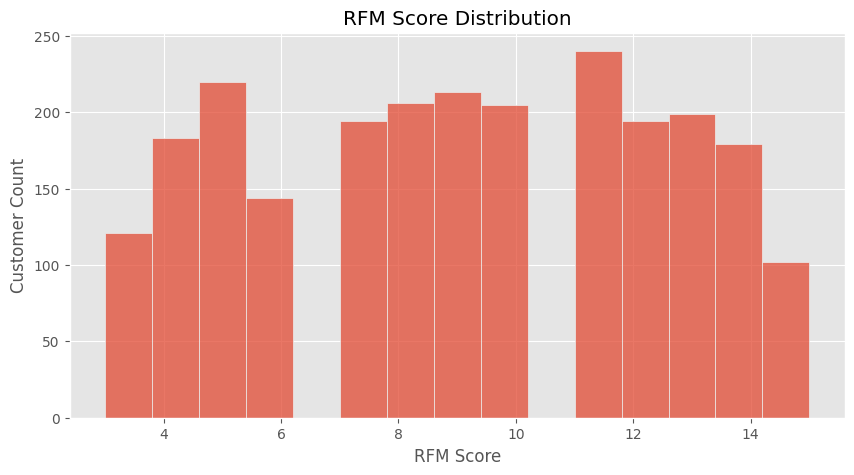

In [17]:
# ============================================================
# RFM SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    rfm["RFM_Score"],
    bins=15
)

plt.title("RFM Score Distribution")

plt.xlabel("RFM Score")

plt.ylabel("Customer Count")

plt.show()

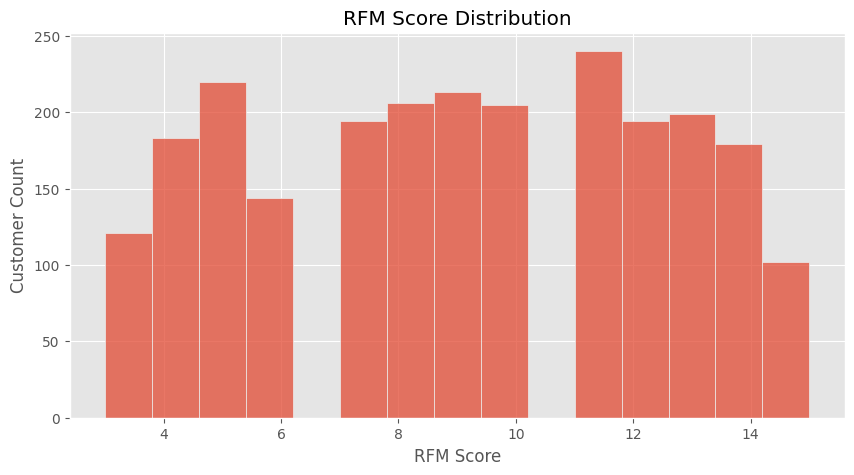

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    rfm["RFM_Score"],
    bins=15
)

plt.title("RFM Score Distribution")

plt.xlabel("RFM Score")

plt.ylabel("Customer Count")

plt.savefig(
    OUTPUT_PATH / "rfm_score_distribution.png",
    bbox_inches="tight"
)

plt.show()

# Analyzing RFM Components

The individual Recency, Frequency, and Monetary distributions provide insight into customer behaviour patterns.

These visualizations help determine suitable segmentation thresholds.

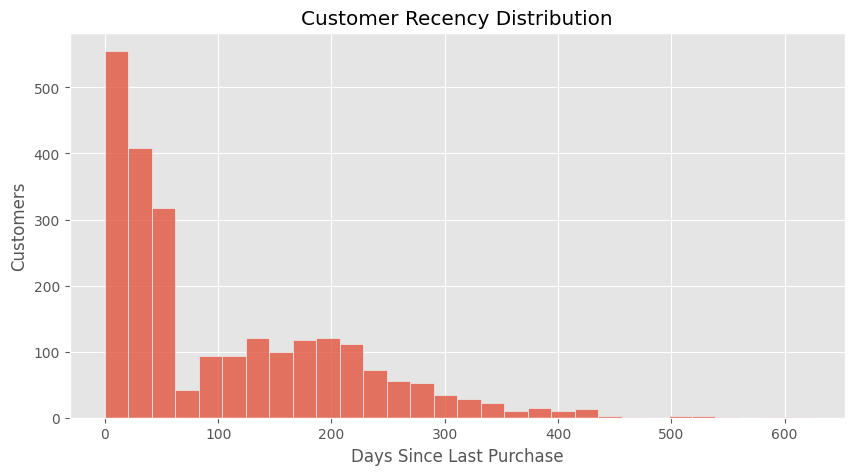

In [19]:
# ============================================================
# RECENCY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    rfm["recency_days"],
    bins=30
)

plt.title("Customer Recency Distribution")

plt.xlabel("Days Since Last Purchase")

plt.ylabel("Customers")

plt.show()

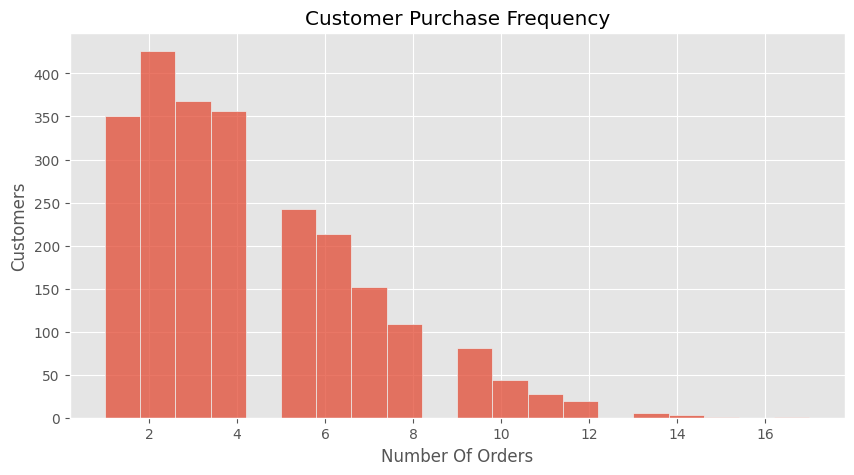

In [20]:
# ============================================================
# FREQUENCY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    rfm["frequency"],
    bins=20
)

plt.title("Customer Purchase Frequency")

plt.xlabel("Number Of Orders")

plt.ylabel("Customers")

plt.show()

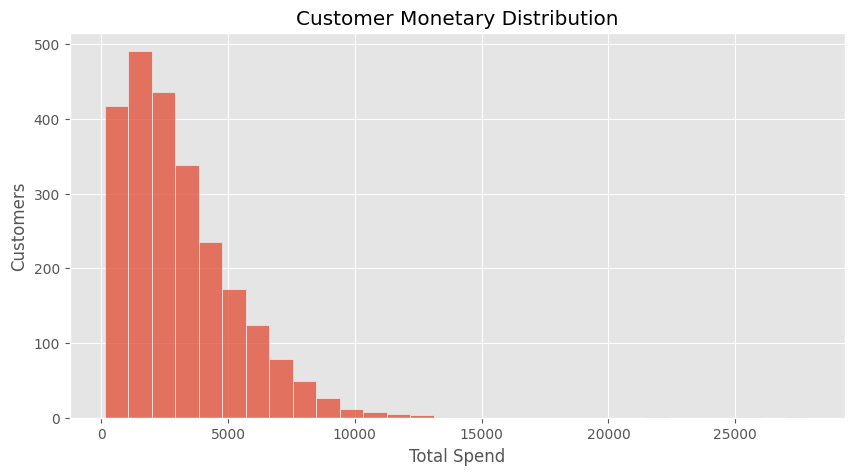

In [21]:
# ============================================================
# MONETARY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    rfm["monetary_value"],
    bins=30
)

plt.title("Customer Monetary Distribution")

plt.xlabel("Total Spend")

plt.ylabel("Customers")

plt.show()

# Initial RFM Insights

The charts above help reveal:

- Purchase recency concentration
- Ordering frequency patterns
- Revenue contribution distribution

These observations will guide customer segmentation logic in the next section.

# RFM Analysis Observations

### Observation 1: Customer Activity Levels

The recency distribution is heavily right-skewed. A large portion of customers have purchased recently, while a smaller group has not interacted with the platform for several months.

This suggests the business has an active customer base but also contains a sizeable dormant segment that may require retention campaigns.

---

### Observation 2: Purchase Frequency Behaviour

Most customers place between 1 and 5 orders. Only a small percentage of customers make frequent repeat purchases.

This indicates that while acquisition appears strong, increasing repeat purchasing behaviour could significantly improve customer lifetime value.

---

### Observation 3: Revenue Contribution

The monetary distribution shows a long-tail pattern. Most customers contribute moderate revenue, while a small number of customers contribute exceptionally high spending.

These high-value customers should receive special attention because losing them would have a disproportionate impact on business revenue.

---

### Observation 4: Customer Heterogeneity

The RFM score distribution is reasonably spread across the score range, indicating the customer base contains multiple behavioural groups rather than a single dominant profile.

This makes customer segmentation meaningful and useful for retention planning.

---

### Observation 5: Retention Opportunity

Customers with low recency scores but historically high monetary and frequency behaviour are likely retention opportunities because they previously demonstrated strong engagement but have recently become inactive.

These customers should be prioritized in retention campaigns before complete churn occurs.

# Additional Behavioural Signals

RFM alone does not capture the complete customer journey.

To improve retention decision quality, additional behavioural indicators are incorporated into the segmentation framework.

The following non-RFM signals will be created:

1. Support Complaint Behaviour
2. Return / Refund Behaviour
3. Campaign Engagement Behaviour
4. Product Category Diversity
5. Loyalty Tier

These signals provide additional insight into customer satisfaction, engagement level, purchasing patterns and retention risk.

In [22]:
# ==========================================================
# SUPPORT COMPLAINT FEATURES
# ==========================================================

ticket_features = (
    support_tickets
    .groupby("customer_id")
    .agg(
        ticket_count=("ticket_id", "count"),
        avg_resolution_hours=("resolution_hours", "mean"),
        avg_sentiment_score=("sentiment_score", "mean"),
        reopened_tickets=("reopened", "sum")
    )
    .reset_index()
)

ticket_features.head()

,customer_id,ticket_count,avg_resolution_hours,avg_sentiment_score,reopened_tickets
0,CUST00001,2,4.35,0.14,0
1,CUST00002,1,1.00,0.00,0
2,CUST00005,1,37.70,-1.00,0
3,CUST00006,2,17.60,-0.68,1
4,CUST00008,1,6.00,0.08,0


# Support Complaint Signal

Customers who frequently raise support tickets may be experiencing friction in their customer journey.

A large number of tickets, long resolution times, negative sentiment scores, or repeated ticket reopening behaviour can indicate dissatisfaction and increased churn risk.

These metrics will later be incorporated into customer segmentation.

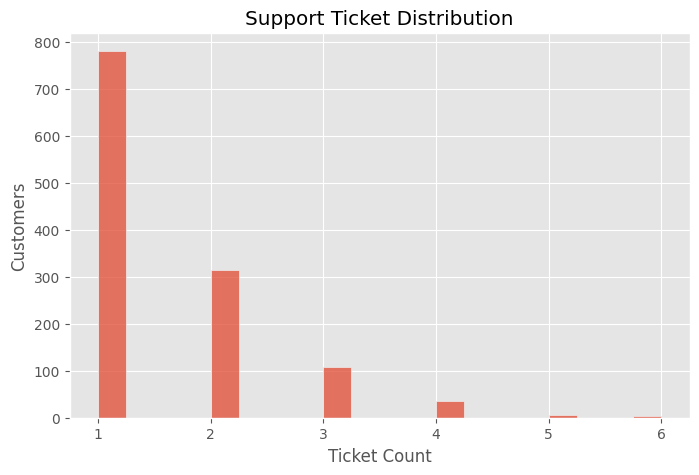

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    ticket_features["ticket_count"],
    bins=20
)

plt.title("Support Ticket Distribution")
plt.xlabel("Ticket Count")
plt.ylabel("Customers")

plt.show()

# Observation

Most customers have relatively few support interactions.

However, a subset of customers generates multiple tickets, indicating possible service dissatisfaction or recurring issues.

Such customers should be monitored carefully because unresolved complaints can accelerate customer churn.

In [24]:
# ==========================================================
# RETURN RATE FEATURES
# ==========================================================

return_features = (
    orders
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "count"),
        returned_orders=("returned", "sum")
    )
    .reset_index()
)

return_features["return_rate"] = (
    return_features["returned_orders"]
    /
    return_features["total_orders"]
)

return_features.head()

,customer_id,total_orders,returned_orders,return_rate
0,CUST00001,6,1,0.166667
1,CUST00002,3,0,0.000000
2,CUST00003,1,0,0.000000
3,CUST00004,1,0,0.000000
4,CUST00005,6,0,0.000000


# Return Behaviour Signal

Frequent product returns often indicate dissatisfaction with product quality, delivery experience or customer expectations.

Customers with unusually high return rates may require intervention even when their spending remains high.

Return behaviour is therefore incorporated into the segmentation process.

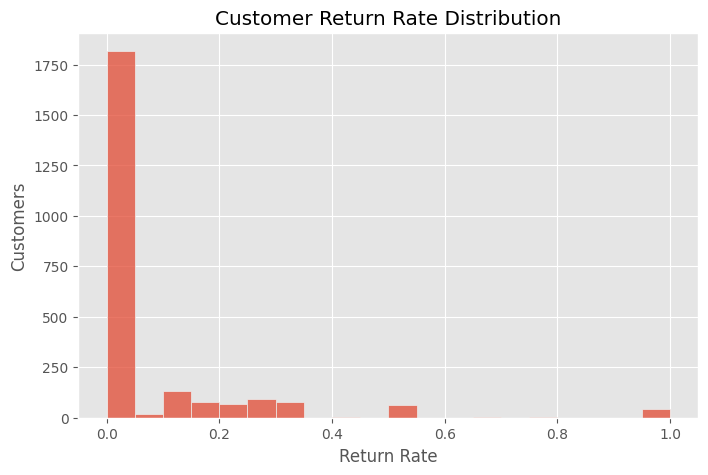

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    return_features["return_rate"],
    bins=20
)

plt.title("Customer Return Rate Distribution")
plt.xlabel("Return Rate")
plt.ylabel("Customers")

plt.show()

# Observation

Most customers exhibit relatively low return behaviour.

However, a smaller group demonstrates consistently elevated return rates, potentially indicating dissatisfaction or mismatch between customer expectations and product offerings.

These customers may require targeted engagement or service improvement initiatives.

In [26]:
# ==========================================================
# CAMPAIGN ENGAGEMENT FEATURES
# ==========================================================

campaign_features = web_events[
    [
        "customer_id",
        "email_opens_30d",
        "campaign_clicks_30d"
    ]
].copy()

campaign_features["engagement_score"] = (
    campaign_features["email_opens_30d"]
    +
    campaign_features["campaign_clicks_30d"]
)

campaign_features.head()

,customer_id,email_opens_30d,campaign_clicks_30d,engagement_score
0,CUST00001,2,0,2
1,CUST00002,0,0,0
2,CUST00003,0,0,0
3,CUST00004,0,0,0
4,CUST00005,3,1,4


# Campaign Engagement Signal

Marketing engagement reflects customer responsiveness to company outreach efforts.

Customers who frequently open emails and click campaigns typically demonstrate stronger brand engagement than customers who ignore marketing communication.

This signal will help distinguish disengaged customers from highly responsive customers.

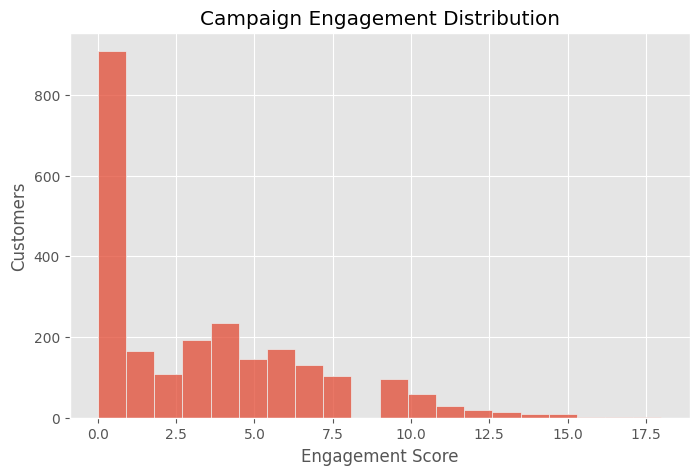

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    campaign_features["engagement_score"],
    bins=20
)

plt.title("Campaign Engagement Distribution")
plt.xlabel("Engagement Score")
plt.ylabel("Customers")

plt.show()

# Observation

Campaign engagement varies substantially across customers.

Highly engaged customers may respond well to retention campaigns, while customers with minimal engagement may require alternative outreach strategies.

In [28]:
# ==========================================================
# CATEGORY DIVERSITY FEATURE
# ==========================================================

category_diversity = (
    orders
    .groupby("customer_id")
    .agg(
        category_diversity=("category", "nunique")
    )
    .reset_index()
)

category_diversity.head()

,customer_id,category_diversity
0,CUST00001,3
1,CUST00002,2
2,CUST00003,1
3,CUST00004,1
4,CUST00005,3


# Category Diversity Signal

Customers purchasing across multiple product categories typically demonstrate broader platform engagement and stronger customer loyalty.

Conversely, customers purchasing from only one category may be more vulnerable to competitive alternatives.

Category diversity therefore provides additional behavioural insight beyond spending alone.

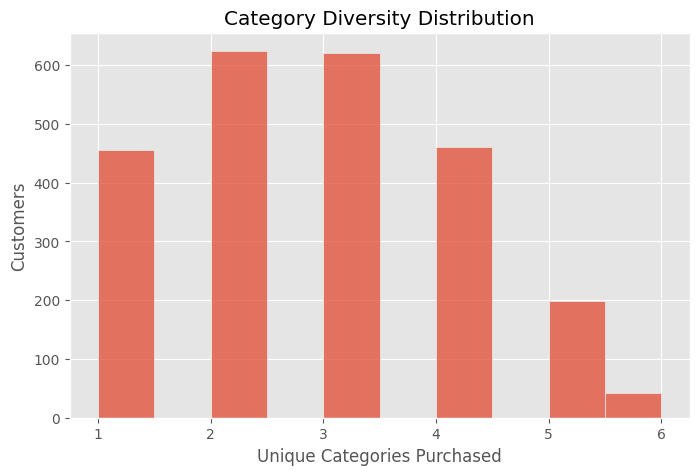

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    category_diversity["category_diversity"],
    bins=10
)

plt.title("Category Diversity Distribution")
plt.xlabel("Unique Categories Purchased")
plt.ylabel("Customers")

plt.show()

# Observation

Customer diversity levels vary considerably.

Customers purchasing across multiple categories appear more deeply embedded within the platform ecosystem and may represent stronger long-term retention opportunities.

In [30]:
# ==========================================================
# LOYALTY TIER FEATURE
# ==========================================================

loyalty_features = customers[
    [
        "customer_id",
        "loyalty_tier"
    ]
].copy()

loyalty_features.head()

,customer_id,loyalty_tier
0,CUST00001,Silver
1,CUST00002,Silver
2,CUST00003,NaN
3,CUST00004,NaN
4,CUST00005,Gold


# Loyalty Tier Signal

Membership programs often reflect historical customer value and engagement.

Higher-tier members generally demonstrate stronger purchasing behaviour and greater lifetime value.

Loyalty tier will therefore be incorporated into the segmentation framework as an additional behavioural signal.

# Customer Segmentation Dataset Creation

The next step is to combine RFM metrics with the additional behavioural signals created previously.

This creates a unified customer-level dataset that captures:

- Purchase recency
- Purchase frequency
- Monetary value
- Support interactions
- Return behaviour
- Campaign engagement
- Product category diversity
- Loyalty membership

The resulting dataset will serve as the foundation for customer segmentation and retention strategy design.

In [36]:
# ============================================================
# MERGE ALL CUSTOMER SIGNALS
# ============================================================

segment_df = rfm.copy()

# Support ticket signals
segment_df = segment_df.merge(
    ticket_features,
    on="customer_id",
    how="left"
)

# Return behaviour signals
segment_df = segment_df.merge(
    return_features[
        [
            "customer_id",
            "return_rate"
        ]
    ],
    on="customer_id",
    how="left"
)

# Campaign engagement signals
segment_df = segment_df.merge(
    campaign_features,
    on="customer_id",
    how="left"
)

# Category diversity
segment_df = segment_df.merge(
    category_diversity,
    on="customer_id",
    how="left"
)

# Loyalty information
segment_df = segment_df.merge(
    loyalty_features,
    on="customer_id",
    how="left"
)

segment_df.head()

,customer_id,last_order_date,recency_days,frequency,monetary_value,R_Score,F_Score,M_Score,RFM_Score,ticket_count,avg_resolution_hours,avg_sentiment_score,reopened_tickets,return_rate,email_opens_30d,campaign_clicks_30d,engagement_score,category_diversity,loyalty_tier
0,CUST00001,2025-06-15,167,6,2955.57,2,4,3,9,2.0,4.35,0.14,0.0,0.166667,2,0,2,3,Silver
1,CUST00002,2025-10-26,34,3,1713.10,4,2,2,8,1.0,1.00,0.00,0.0,0.000000,0,0,0,2,Silver
2,CUST00003,2025-04-12,231,1,649.98,1,1,1,3,NaN,NaN,NaN,NaN,0.000000,0,0,0,1,NaN
3,CUST00004,2025-05-22,191,1,1604.04,2,1,2,5,NaN,NaN,NaN,NaN,0.000000,0,0,0,1,NaN
4,CUST00005,2025-11-19,10,6,3910.43,5,4,4,13,1.0,37.70,-1.00,0.0,0.000000,3,1,4,3,Gold


In [41]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

segment_df["ticket_count"] = (
    segment_df["ticket_count"]
    .fillna(0)
)

segment_df["avg_resolution_hours"] = (
    segment_df["avg_resolution_hours"]
    .fillna(0)
)

segment_df["avg_sentiment_score"] = (
    segment_df["avg_sentiment_score"]
    .fillna(0)
)

segment_df["reopened_tickets"] = (
    segment_df["reopened_tickets"]
    .fillna(0)
)

segment_df["return_rate"] = (
    segment_df["return_rate"]
    .fillna(0)
)

segment_df["email_opens_30d"] = (
    segment_df["email_opens_30d"]
    .fillna(0)
)

segment_df["campaign_clicks_30d"] = (
    segment_df["campaign_clicks_30d"]
    .fillna(0)
)

segment_df["engagement_score"] = (
    segment_df["engagement_score"]
    .fillna(0)
)

segment_df["category_diversity"] = (
    segment_df["category_diversity"]
    .fillna(1)
)

segment_df["loyalty_tier"] = (
    segment_df["loyalty_tier"]
    .fillna("No Tier")
)

segment_df.isnull().sum()

customer_id             0
last_order_date         0
recency_days            0
frequency               0
monetary_value          0
R_Score                 0
F_Score                 0
M_Score                 0
RFM_Score               0
ticket_count            0
avg_resolution_hours    0
avg_sentiment_score     0
reopened_tickets        0
return_rate             0
email_opens_30d         0
campaign_clicks_30d     0
engagement_score        0
category_diversity      0
loyalty_tier            0
dtype: int64

# Segmentation Logic

Customer segments are not assigned randomly.

Each segment is defined using a combination of:

- RFM scores
- Customer activity level
- Return behaviour
- Support ticket behaviour
- Marketing engagement
- Loyalty indicators

The objective is to identify customers requiring different retention actions.

Seven segments are created:

1. Champions
2. Loyal Customers
3. New Customers
4. At-Risk Customers
5. Dormant Customers
6. Discount-Sensitive Customers
7. High-Value Unhappy Customers

The logic behind each segment is explicitly documented below.

In [42]:
# ============================================================
# FINAL DATASET CHECK
# ============================================================

print("Rows :", segment_df.shape[0])
print("Columns :", segment_df.shape[1])

segment_df.head()

Rows : 2400
Columns : 19


,customer_id,last_order_date,recency_days,frequency,monetary_value,R_Score,F_Score,M_Score,RFM_Score,ticket_count,avg_resolution_hours,avg_sentiment_score,reopened_tickets,return_rate,email_opens_30d,campaign_clicks_30d,engagement_score,category_diversity,loyalty_tier
0,CUST00001,2025-06-15,167,6,2955.57,2,4,3,9,2.0,4.35,0.14,0.0,0.166667,2,0,2,3,Silver
1,CUST00002,2025-10-26,34,3,1713.10,4,2,2,8,1.0,1.00,0.00,0.0,0.000000,0,0,0,2,Silver
2,CUST00003,2025-04-12,231,1,649.98,1,1,1,3,0.0,0.00,0.00,0.0,0.000000,0,0,0,1,No Tier
3,CUST00004,2025-05-22,191,1,1604.04,2,1,2,5,0.0,0.00,0.00,0.0,0.000000,0,0,0,1,No Tier
4,CUST00005,2025-11-19,10,6,3910.43,5,4,4,13,1.0,37.70,-1.00,0.0,0.000000,3,1,4,3,Gold


In [43]:
# ============================================================
# VERIFY AVAILABLE FEATURES
# ============================================================

segment_df.columns.tolist()

['customer_id',
 'last_order_date',
 'recency_days',
 'frequency',
 'monetary_value',
 'R_Score',
 'F_Score',
 'M_Score',
 'RFM_Score',
 'ticket_count',
 'avg_resolution_hours',
 'avg_sentiment_score',
 'reopened_tickets',
 'return_rate',
 'email_opens_30d',
 'campaign_clicks_30d',
 'engagement_score',
 'category_diversity',
 'loyalty_tier']

In [44]:
segment_df.columns.tolist()

['customer_id',
 'last_order_date',
 'recency_days',
 'frequency',
 'monetary_value',
 'R_Score',
 'F_Score',
 'M_Score',
 'RFM_Score',
 'ticket_count',
 'avg_resolution_hours',
 'avg_sentiment_score',
 'reopened_tickets',
 'return_rate',
 'email_opens_30d',
 'campaign_clicks_30d',
 'engagement_score',
 'category_diversity',
 'loyalty_tier']

# Customer Segmentation Strategy

To convert customer behaviour into actionable business insights, customers are grouped into meaningful retention segments.

The segmentation is based on three core RFM dimensions:

- Recency (How recently the customer purchased)
- Frequency (How often the customer purchases)
- Monetary Value (How much revenue the customer generates)

In addition to RFM, behavioural signals are incorporated:

- Support ticket activity
- Return behaviour
- Campaign engagement
- Category diversity
- Loyalty membership
- Discount usage

Using both transactional and behavioural signals creates richer and more realistic customer segments for retention planning.

In [45]:
# ==========================================================
# DETERMINE BUSINESS THRESHOLDS
# ==========================================================

high_spend_threshold = segment_df["monetary_value"].quantile(0.75)

high_ticket_threshold = segment_df["ticket_count"].quantile(0.75)

high_return_threshold = segment_df["return_rate"].quantile(0.75)

print("High Spend Threshold :", round(high_spend_threshold, 2))
print("High Ticket Threshold :", round(high_ticket_threshold, 2))
print("High Return Threshold :", round(high_return_threshold, 2))

High Spend Threshold : 4253.45
High Ticket Threshold : 1.0
High Return Threshold : 0.0


# Segment Definitions

### Champions

- R Score ≥ 4
- F Score ≥ 4
- M Score ≥ 4

These customers purchase frequently, spend heavily and have purchased recently.

---

### Loyal Customers

- High Frequency Score
- Consistent purchasing behaviour

These customers form the core customer base and should be retained through loyalty programs.

---

### New Customers

- Highest Recency Score
- Low Frequency

These customers have recently joined and require onboarding and nurturing campaigns.

---

### At Risk Customers

- Historically valuable customers
- Low Recency Score

These customers are showing signs of disengagement.

---

### Dormant Customers

- Lowest Recency Score
- Limited recent activity

These customers have become inactive and require reactivation campaigns.

---

### Discount Sensitive Customers

- High average discount usage

These customers respond strongly to promotional offers.

---

### High Value Unhappy Customers

- High monetary contribution
- High support burden and/or high return behaviour

These customers contribute significant revenue but show dissatisfaction signals.

---

### Regular Customers

Customers not falling into any specific risk or opportunity segment.

In [46]:
# ==========================================================
# CUSTOMER DISCOUNT USAGE
# ==========================================================

discount_features = (
    orders
    .groupby("customer_id")
    .agg(
        avg_discount_pct=("discount_pct", "mean")
    )
    .reset_index()
)

segment_df = segment_df.merge(
    discount_features,
    on="customer_id",
    how="left"
)

segment_df["avg_discount_pct"] = (
    segment_df["avg_discount_pct"]
    .fillna(0)
)

segment_df.head()

,customer_id,last_order_date,recency_days,frequency,monetary_value,R_Score,F_Score,M_Score,RFM_Score,ticket_count,avg_resolution_hours,avg_sentiment_score,reopened_tickets,return_rate,email_opens_30d,campaign_clicks_30d,engagement_score,category_diversity,loyalty_tier,avg_discount_pct
0,CUST00001,2025-06-15,167,6,2955.57,2,4,3,9,2.0,4.35,0.14,0.0,0.166667,2,0,2,3,Silver,0.363333
1,CUST00002,2025-10-26,34,3,1713.10,4,2,2,8,1.0,1.00,0.00,0.0,0.000000,0,0,0,2,Silver,0.190000
2,CUST00003,2025-04-12,231,1,649.98,1,1,1,3,0.0,0.00,0.00,0.0,0.000000,0,0,0,1,No Tier,0.470000
3,CUST00004,2025-05-22,191,1,1604.04,2,1,2,5,0.0,0.00,0.00,0.0,0.000000,0,0,0,1,No Tier,0.160000
4,CUST00005,2025-11-19,10,6,3910.43,5,4,4,13,1.0,37.70,-1.00,0.0,0.000000,3,1,4,3,Gold,0.388333


In [47]:
# ==========================================================
# DISCOUNT THRESHOLD
# ==========================================================

discount_sensitive_threshold = (
    segment_df["avg_discount_pct"]
    .quantile(0.75)
)

print(
    "Discount Sensitive Threshold:",
    round(discount_sensitive_threshold, 2)
)

Discount Sensitive Threshold: 0.33


In [51]:
# ==========================================================
# CUSTOMER SEGMENT ASSIGNMENT
# ==========================================================

def assign_segment(row):

    # Champions
    if (
        row["R_Score"] >= 4 and
        row["F_Score"] >= 4 and
        row["M_Score"] >= 4
    ):
        return "Champions"

    # High Value Unhappy
    elif (
        row["monetary_value"] >= high_spend_threshold and
        (
            row["ticket_count"] >= high_ticket_threshold or
            row["return_rate"] >= high_return_threshold
        )
    ):
        return "High Value Unhappy"

    # At Risk
    elif (
        row["R_Score"] <= 2 and
        row["M_Score"] >= 4
    ):
        return "At Risk"

    # Dormant
    elif row["R_Score"] == 1:
        return "Dormant"

    # New Customers
    elif (
        row["R_Score"] == 5 and
        row["frequency"] <= 2
    ):
        return "New Customers"

    # Discount Sensitive
    elif (
        row["avg_discount_pct"] >= discount_sensitive_threshold
    ):
        return "Discount Sensitive"

    # Loyal Customers
    elif (
        row["F_Score"] >= 4
    ):
        return "Loyal Customers"

    # Default
    else:
        return "Regular Customers"

In [52]:
segment_df["segment_name"] = (
    segment_df.apply(
        assign_segment,
        axis=1
    )
)

segment_df[
    [
        "customer_id",
        "segment_name"
    ]
].head()

,customer_id,segment_name
0,CUST00001,Discount Sensitive
1,CUST00002,Regular Customers
2,CUST00003,Dormant
3,CUST00004,Regular Customers
4,CUST00005,Champions


# Exporting Final Customer Segments

The final customer segmentation dataset is exported as `segments.csv`.

Along with the assigned customer segment, the file includes all major features used during segmentation so that business stakeholders can understand why each customer belongs to a particular segment.

The exported file will be used for retention planning, campaign targeting and manual review.

In [53]:
# ==========================================================
# EXPORT FINAL CUSTOMER SEGMENTS
# ==========================================================

segments_export = segment_df[
    [
        "customer_id",
        "segment_name",

        # RFM Features
        "recency_days",
        "frequency",
        "monetary_value",

        # RFM Scores
        "R_Score",
        "F_Score",
        "M_Score",
        "RFM_Score",

        # Support Signals
        "ticket_count",
        "avg_resolution_hours",
        "avg_sentiment_score",
        "reopened_tickets",

        # Return Behaviour
        "return_rate",

        # Campaign Engagement
        "email_opens_30d",
        "campaign_clicks_30d",
        "engagement_score",

        # Additional Signals
        "category_diversity",
        "loyalty_tier",
        "avg_discount_pct"
    ]
].copy()

segments_export.to_csv(
    OUTPUT_PATH / "segments.csv",
    index=False
)

print("segments.csv saved successfully")
print()
print("Shape :", segments_export.shape)

segments_export.head()

segments.csv saved successfully

Shape : (2400, 20)


,customer_id,segment_name,recency_days,frequency,monetary_value,R_Score,F_Score,M_Score,RFM_Score,ticket_count,avg_resolution_hours,avg_sentiment_score,reopened_tickets,return_rate,email_opens_30d,campaign_clicks_30d,engagement_score,category_diversity,loyalty_tier,avg_discount_pct
0,CUST00001,Discount Sensitive,167,6,2955.57,2,4,3,9,2.0,4.35,0.14,0.0,0.166667,2,0,2,3,Silver,0.363333
1,CUST00002,Regular Customers,34,3,1713.10,4,2,2,8,1.0,1.00,0.00,0.0,0.000000,0,0,0,2,Silver,0.190000
2,CUST00003,Dormant,231,1,649.98,1,1,1,3,0.0,0.00,0.00,0.0,0.000000,0,0,0,1,No Tier,0.470000
3,CUST00004,Regular Customers,191,1,1604.04,2,1,2,5,0.0,0.00,0.00,0.0,0.000000,0,0,0,1,No Tier,0.160000
4,CUST00005,Champions,10,6,3910.43,5,4,4,13,1.0,37.70,-1.00,0.0,0.000000,3,1,4,3,Gold,0.388333


In [54]:
# ==========================================================
# VERIFYING EXPORT
# ==========================================================

saved_segments = pd.read_csv(
    OUTPUT_PATH / "segments.csv"
)

print("Rows :", saved_segments.shape[0])
print("Columns :", saved_segments.shape[1])

saved_segments.head()

Rows : 2400
Columns : 20


,customer_id,segment_name,recency_days,frequency,monetary_value,R_Score,F_Score,M_Score,RFM_Score,ticket_count,avg_resolution_hours,avg_sentiment_score,reopened_tickets,return_rate,email_opens_30d,campaign_clicks_30d,engagement_score,category_diversity,loyalty_tier,avg_discount_pct
0,CUST00001,Discount Sensitive,167,6,2955.57,2,4,3,9,2.0,4.35,0.14,0.0,0.166667,2,0,2,3,Silver,0.363333
1,CUST00002,Regular Customers,34,3,1713.10,4,2,2,8,1.0,1.00,0.00,0.0,0.000000,0,0,0,2,Silver,0.190000
2,CUST00003,Dormant,231,1,649.98,1,1,1,3,0.0,0.00,0.00,0.0,0.000000,0,0,0,1,No Tier,0.470000
3,CUST00004,Regular Customers,191,1,1604.04,2,1,2,5,0.0,0.00,0.00,0.0,0.000000,0,0,0,1,No Tier,0.160000
4,CUST00005,Champions,10,6,3910.43,5,4,4,13,1.0,37.70,-1.00,0.0,0.000000,3,1,4,3,Gold,0.388333


# Retention Strategy Framework

Customer segments were created using a combination of RFM metrics and additional behavioural signals such as support interactions, return behaviour, campaign engagement, loyalty tier, category diversity and discount dependency.

The objective is not only to identify churn risk but also to recommend practical actions that maximize customer lifetime value while efficiently utilizing retention budgets.

Each segment receives a customized retention strategy based on customer behaviour, business value and probability of churn.

# Retention Recommendations

## Champions

Characteristics:
- High recency
- High frequency
- High monetary value

Recommended Actions:
- VIP loyalty benefits
- Early access to product launches
- Referral rewards
- Exclusive membership perks

Expected Business Impact:
Highest customer lifetime value preservation.

---

## Loyal Customers

Characteristics:
- Frequent purchases
- Consistent engagement

Recommended Actions:
- Personalized recommendations
- Cross-selling campaigns
- Loyalty point acceleration

Expected Business Impact:
Revenue growth through increased basket size.

---

## New Customers

Characteristics:
- Recently acquired
- Low purchase history

Recommended Actions:
- Welcome journeys
- Onboarding emails
- First repeat-purchase incentives

Expected Business Impact:
Improved customer retention during initial lifecycle stage.

---

## At Risk Customers

Characteristics:
- Previously valuable
- Declining activity

Recommended Actions:
- Win-back campaigns
- Personalized offers
- Reminder communications

Expected Business Impact:
Recovery of customers before churn occurs.

---

## Dormant Customers

Characteristics:
- Long inactivity periods

Recommended Actions:
- Aggressive reactivation campaigns
- Limited-time offers
- Exit surveys

Expected Business Impact:
Selective recovery of lost customers.

---

## Discount Sensitive Customers

Characteristics:
- Strong dependence on promotions

Recommended Actions:
- Targeted coupon campaigns
- Flash-sale notifications
- Dynamic discounting

Expected Business Impact:
Revenue generation without excessive blanket discounts.

---

## High Value Unhappy Customers

Characteristics:
- High spending
- High complaint volume or return rate

Recommended Actions:
- Dedicated customer support
- Priority issue resolution
- Relationship recovery outreach

Expected Business Impact:
Protection of high-value revenue streams.

---

## Regular Customers

Characteristics:
- Moderate behaviour across all metrics

Recommended Actions:
- Personalized engagement
- Product discovery campaigns
- Seasonal promotions

Expected Business Impact:
Migration into higher-value segments.

# Campaign Budget Prioritization

Assume a limited retention budget of ₹1,00,000.

Instead of distributing resources equally across all segments, budget allocation should prioritize customers with the highest potential return on investment.

Priority Ranking:

1. High Value Unhappy Customers
2. At Risk Customers
3. Champions
4. Loyal Customers
5. New Customers
6. Discount Sensitive Customers
7. Regular Customers
8. Dormant Customers

Reasoning:

High Value Unhappy Customers generate substantial revenue but exhibit dissatisfaction indicators. Small interventions can prevent significant revenue loss.

At Risk Customers have historical purchasing value and can often be reactivated at relatively low cost.

Champions and Loyal Customers should receive retention benefits to maintain satisfaction but generally require less intervention.

Dormant Customers receive the lowest budget allocation because recovery probability is comparatively low.

Suggested Budget Allocation:

- High Value Unhappy: 30%
- At Risk: 25%
- Champions: 15%
- Loyal Customers: 10%
- New Customers: 8%
- Discount Sensitive: 5%
- Regular Customers: 4%
- Dormant Customers: 3%

In [56]:
budget_df = pd.DataFrame({
    "Segment": [
        "High Value Unhappy",
        "At Risk",
        "Champions",
        "Loyal Customers",
        "New Customers",
        "Discount Sensitive",
        "Regular Customers",
        "Dormant"
    ],
    "Budget_Percent": [
        30,
        25,
        15,
        10,
        8,
        5,
        4,
        3
    ]
})

budget_df["Budget_Amount"] = (
    budget_df["Budget_Percent"] / 100
) * 100000

budget_df

,Segment,Budget_Percent,Budget_Amount
0,High Value Unhappy,30,30000.0
1,At Risk,25,25000.0
2,Champions,15,15000.0
3,Loyal Customers,10,10000.0
4,New Customers,8,8000.0
5,Discount Sensitive,5,5000.0
6,Regular Customers,4,4000.0
7,Dormant,3,3000.0


In [57]:
manual_review = segment_df.copy()

manual_review["review_score"] = (
    manual_review["ticket_count"] +
    manual_review["return_rate"] * 100 +
    abs(manual_review["R_Score"] - manual_review["F_Score"])
)

manual_review_cases = (
    manual_review
    .sort_values(
        "review_score",
        ascending=False
    )
    .head(15)
)

manual_review_cases[
    [
        "customer_id",
        "segment_name",
        "recency_days",
        "frequency",
        "monetary_value",
        "ticket_count",
        "return_rate"
    ]
]

,customer_id,segment_name,recency_days,frequency,monetary_value,ticket_count,return_rate
437,CUST00438,Regular Customers,124,3,2466.39,3.0,1.0
1878,CUST01879,Regular Customers,84,1,709.74,1.0,1.0
941,CUST00942,Discount Sensitive,67,1,407.18,1.0,1.0
961,CUST00962,Regular Customers,82,1,349.41,1.0,1.0
107,CUST00108,Regular Customers,104,1,1074.50,1.0,1.0
1152,CUST01153,Discount Sensitive,93,1,714.43,1.0,1.0
413,CUST00414,Regular Customers,63,1,311.44,1.0,1.0
614,CUST00615,Regular Customers,94,1,446.03,1.0,1.0
2036,CUST02037,Regular Customers,61,2,1131.94,2.0,1.0
721,CUST00722,Discount Sensitive,90,1,256.54,1.0,1.0


# Manual Review Cases

The following 15 customers were selected for manual review because their retention decision is not straightforward. They exhibit conflicting behavioural indicators such as:

- High spending but low engagement.
- High engagement but increasing complaint rates.
- Strong purchase history but recent inactivity.
- High campaign response but elevated return behaviour.

These customers require individual evaluation before final retention decisions are executed.